# 02 Marker Gene Analysis

This notebook identifies marker genes for major immune cell populations in the inflammatory bowel disease single-cell RNA-seq dataset.

The analysis uses the immune-cell AnnData object saved from the initial data exploration notebook.

## 1. Setup

Import analysis libraries and configure plotting settings.

In [15]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, facecolor="white")

## 2. Load Processed Immune Cell Dataset

Load the immune-cell AnnData object generated in the data exploration notebook.

In [16]:
processed_data_path = Path("../data/processed/immune_cells_with_metadata.h5ad")

adata = sc.read_h5ad(processed_data_path)

adata

AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'

In [17]:
adata.obs[["Cluster", "Health", "Subject", "Sample"]].head()

,Cluster,Health,Subject,Sample
N7.EpiA.AAGGCTACCCTTTA,Plasma,Non-inflamed,N7,N7.EpiA
N7.EpiA.AAGGTGCTACGGAG,CD8+ IELs,Non-inflamed,N7,N7.EpiA
N7.EpiA.AAGTAACTTGCTTT,CD8+ IELs,Non-inflamed,N7,N7.EpiA
N7.EpiA.ACAATAACCCTCAC,Plasma,Non-inflamed,N7,N7.EpiA
N7.EpiA.ACAGTTCTTCTACT,CD8+ IELs,Non-inflamed,N7,N7.EpiA


## 3. Prepare Expression Data

Marker gene testing works best on normalized and log-transformed expression values. The raw count matrix is preserved in a separate layer before normalization.

In [18]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

normalizing counts per cell
    finished (0:00:04)


AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'
    uns: 'log1p'
    layers: 'counts'

## 4. Identify Marker Genes By Immune Cluster

Marker genes are identified for each immune cluster by comparing cells in one cluster against all other immune cells.

In [19]:
sc.tl.rank_genes_groups(
    adata,
    groupby="Cluster",
    method="wilcoxon",
    key_added="cluster_markers"
)

ranking genes
    finished: added to `.uns['cluster_markers']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:08:57)


C:\Users\Shane Thomas\PycharmProjects\scRNAseq-immune-atlas\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\Shane Thomas\PycharmProjects\scRNAseq-immune-atlas\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\Shane Thomas\PycharmProjects\scRNAseq-immune-atlas\.venv\Lib\s

## 6. Convert Marker Gene Results To Tables

The Scanpy marker gene results are converted into tidy tables so they can be inspected, filtered, saved, and reused outside the notebook.

In [20]:
marker_table = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="cluster_markers"
)

marker_table.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,CD4+ Activated Fos-hi,IL32,104.799377,3.351241,0.0,0.0
1,CD4+ Activated Fos-hi,S100A4,104.717209,2.976298,0.0,0.0
2,CD4+ Activated Fos-hi,TRAC,99.977127,3.066901,0.0,0.0
3,CD4+ Activated Fos-hi,CD69,98.579559,2.999210,0.0,0.0
4,CD4+ Activated Fos-hi,ANXA1,96.558731,3.292159,0.0,0.0


## 7. Inspect Top Marker Genes Per Cluster

The top marker genes for each immune cluster are inspected to evaluate whether cluster annotations match expected immune cell biology.

In [21]:
top_markers = (
    marker_table
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(5)
)

top_markers[["group", "names", "scores", "logfoldchanges", "pvals_adj"]].head(30)

C:\Users\Shane Thomas\AppData\Local\Temp\ipykernel_8484\1425819254.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


,group,names,scores,logfoldchanges,pvals_adj
0,CD4+ Activated Fos-hi,IL32,104.799377,3.351241,0.000000e+00
1,CD4+ Activated Fos-hi,S100A4,104.717209,2.976298,0.000000e+00
2,CD4+ Activated Fos-hi,TRAC,99.977127,3.066901,0.000000e+00
3,CD4+ Activated Fos-hi,CD69,98.579559,2.999210,0.000000e+00
4,CD4+ Activated Fos-hi,ANXA1,96.558731,3.292159,0.000000e+00
20529,CD4+ Activated Fos-lo,ANXA1,100.913422,3.489706,0.000000e+00
20530,CD4+ Activated Fos-lo,S100A4,98.502777,2.922632,0.000000e+00
20531,CD4+ Activated Fos-lo,EEF1A1,96.151260,1.090559,0.000000e+00
20532,CD4+ Activated Fos-lo,RPS3,93.323006,1.172647,0.000000e+00
20533,CD4+ Activated Fos-lo,TRAC,93.301575,2.988388,0.000000e+00


## 8. Inspect Selected Immune Populations

A subset of biologically interpretable immune populations is inspected more closely. This provides a clearer validation step than viewing every cluster at once.

In [22]:
selected_clusters = [
    "Plasma",
    "CD4+ Memory",
    "Macrophages",
    "CD8+ LP",
    "Tregs",
    "CD69+ Mast",
]

selected_top_markers = (
    marker_table[marker_table["group"].isin(selected_clusters)]
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(8)
)

selected_top_markers[["group", "names", "scores", "logfoldchanges", "pvals_adj"]]

C:\Users\Shane Thomas\AppData\Local\Temp\ipykernel_8484\2959718124.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


,group,names,scores,logfoldchanges,pvals_adj
41058,CD4+ Memory,RPS27,176.866089,1.498222,0.0
41059,CD4+ Memory,RPL32,173.644043,1.197703,0.0
41060,CD4+ Memory,RPS15A,171.065506,1.241505,0.0
41061,CD4+ Memory,RPL31,168.414749,1.496834,0.0
41062,CD4+ Memory,RPS12,168.106461,1.389745,0.0
41063,CD4+ Memory,EEF1A1,167.804962,1.164718,0.0
41064,CD4+ Memory,RPS6,167.347351,1.095348,0.0
41065,CD4+ Memory,RPL13,167.009720,0.941557,0.0
123174,CD8+ LP,CCL5,176.476746,6.137530,0.0
123175,CD8+ LP,NKG7,144.509628,5.780817,0.0


## 9. Save Marker Gene Tables

The full marker gene table and selected-cluster marker table are saved as project outputs.

In [23]:
marker_table_path = "../results/tables/cluster_marker_genes_all.csv"
selected_marker_table_path = "../results/tables/selected_cluster_marker_genes.csv"

marker_table.to_csv(marker_table_path, index=False)
selected_top_markers.to_csv(selected_marker_table_path, index=False)

marker_table_path, selected_marker_table_path

('../results/tables/cluster_marker_genes_all.csv',
 '../results/tables/selected_cluster_marker_genes.csv')

## 10. Initial Marker Gene Interpretation

The marker gene results support the broad immune cluster annotations. For example, activated CD4+ T cell clusters show T cell-associated and activation-related genes such as `TRAC`, `CD69`, `IL32`, and `S100A4`.

These results suggest that the dataset's immune cluster labels capture biologically meaningful cell states. The next analysis step will visualize canonical immune marker genes across clusters to further validate major immune identities.

## 11. Visualize Canonical Immune Marker Genes

Canonical immune marker genes are visualized across clusters to further validate major immune cell identities. Dot plots show both the average expression level and the fraction of cells expressing each marker within each cluster.

In [24]:
canonical_markers = {
    "T cells": ["CD3D", "CD3E", "TRAC"],
    "CD4 / memory T cells": ["CD4", "IL7R", "CCR7"],
    "CD8 T cells": ["CD8A", "CD8B", "GZMK"],
    "Regulatory T cells": ["FOXP3", "IL2RA", "CTLA4"],
    "B / plasma cells": ["MS4A1", "CD79A", "MZB1", "JCHAIN"],
    "Myeloid cells": ["LYZ", "S100A8", "S100A9", "FCGR3A"],
    "Mast cells": ["TPSAB1", "TPSB2", "KIT"],
}

available_markers = {
    group: [gene for gene in genes if gene in adata.var_names]
    for group, genes in canonical_markers.items()
}

available_markers

{'T cells': ['CD3D', 'CD3E', 'TRAC'],
 'CD4 / memory T cells': ['CD4', 'IL7R', 'CCR7'],
 'CD8 T cells': ['CD8A', 'CD8B', 'GZMK'],
 'Regulatory T cells': ['FOXP3', 'IL2RA', 'CTLA4'],
 'B / plasma cells': ['MS4A1', 'CD79A', 'MZB1'],
 'Myeloid cells': ['LYZ', 'S100A8', 'S100A9', 'FCGR3A'],
 'Mast cells': ['TPSAB1', 'KIT']}

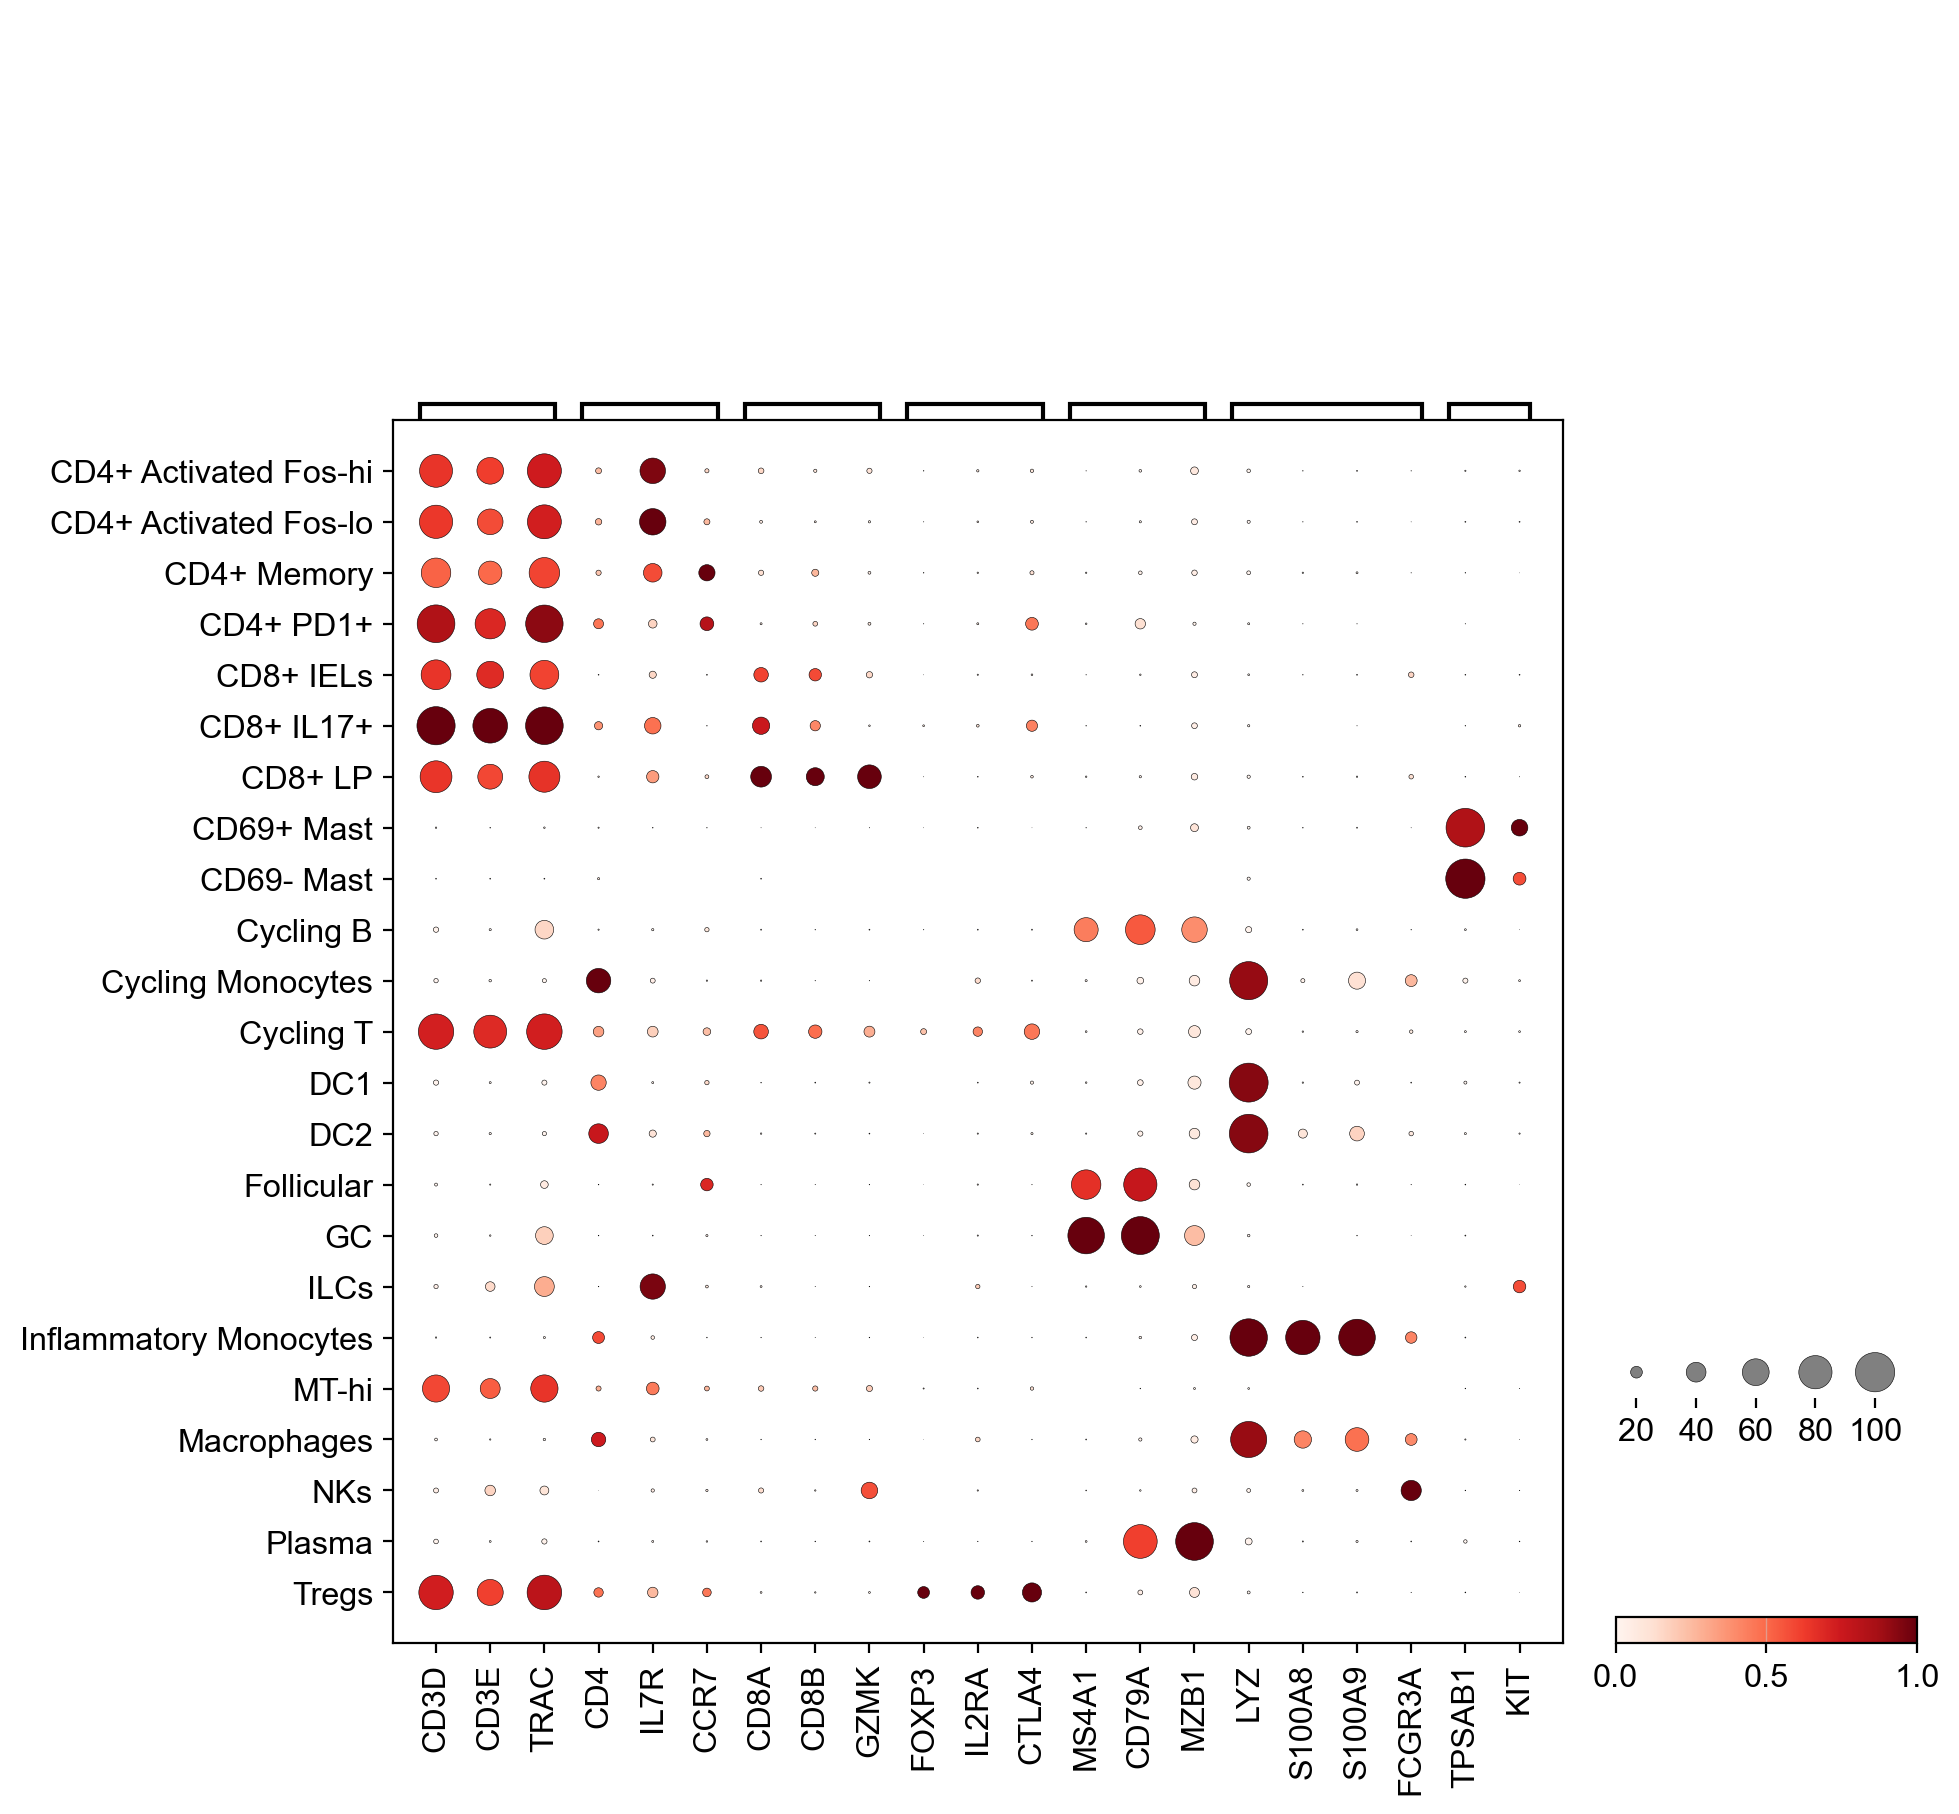

In [25]:
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="Cluster",
    standard_scale="var",
    dendrogram=False,
    show=False
)

plt.savefig(
    "../results/figures/canonical_marker_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Canonical Marker Interpretation

The canonical marker dot plot supports the major immune cluster annotations in the dataset. T cell-associated clusters show strong expression of `CD3D`, `CD3E`, and `TRAC`, confirming their T cell identity. CD4-associated clusters also show expression of markers such as `CD4`, `IL7R`, and `CCR7`, while CD8-associated clusters show expression of `CD8A`, `CD8B`, and the cytotoxic marker `GZMK`.

Regulatory T cell identity is supported by expression of `FOXP3`, `IL2RA`, and `CTLA4` in the Treg cluster. B cell and plasma cell populations are supported by expression of `MS4A1`, `CD79A`, `MZB1`, and `JCHAIN`, with plasma cells showing strong expression of antibody-secreting cell markers. Myeloid populations show expression of `LYZ`, `S100A8`, and `S100A9`, consistent with monocyte/macrophage identity. Mast cell clusters are supported by expression of `TPSAB1` and `KIT`.

Overall, the marker expression patterns are consistent with expected immune lineage biology. This supports the use of the provided cluster annotations for downstream analysis of disease-associated immune changes across healthy, non-inflamed, and inflamed intestinal tissue.

## 12. Notebook Summary

This notebook identified marker genes for immune cell clusters in the inflammatory bowel disease single-cell RNA-seq dataset. Statistical marker gene ranking was used to identify cluster-enriched genes, and canonical immune marker visualization was used to validate major immune population labels.

The marker gene results support the biological interpretation of major immune clusters, including T cells, regulatory T cells, B/plasma cells, myeloid cells, and mast cells. These validated cluster annotations provide a foundation for downstream analysis of disease-associated immune changes across healthy, non-inflamed, and inflamed intestinal tissue.